# ContinuousTimeRNN Exploration: Parameter Effects on Trace Variability

This notebook explores how different parameters affect the dynamics and trace variability of `ContinuousTimeRNN` systems.

Key parameters to explore:
- **spectral_radius**: Controls recurrent weight magnitude (affects stability/memory)
- **sparsity**: Fraction of non-zero recurrent connections
- **tau**: Timescale(s) for hidden state decay (controls speed of dynamics)
- **n_hidden**: Number of hidden units (affects representational capacity)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from neurosignature.systems import ContinuousTimeRNN, SystemGenerator
from neurosignature.simulation import Simulator
from neurosignature.visualization import plot_traces

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Basic System Setup and Single Trace

Create a basic ContinuousTimeRNN and visualize its output traces.

In [2]:
# System parameters
n_hidden = 64
n_inputs = 10
n_outputs = 5
duration_ms = 500
dt_ms = 1.0
n_steps = int(duration_ms / dt_ms)

# Create a basic system
system = ContinuousTimeRNN(
    n_hidden=n_hidden,
    n_inputs=n_inputs,
    n_outputs=n_outputs,
    spectral_radius=0.8,
    sparsity=0.1,
    seed=42
)

# Generate random input
rng = np.random.default_rng(42)
inputs = rng.standard_normal((n_steps, n_inputs)) * 0.5

# Simulate
simulator = Simulator(system, dt_ms=dt_ms)
outputs, states = simulator.run(inputs, record_states=True)

print(f"Output shape: {outputs.shape}")
print(f"States shape: {states.shape}")
print(f"Tau range: {system.tau.min():.1f} - {system.tau.max():.1f} ms")

Output shape: (500, 5)
States shape: (500, 64)
Tau range: 10.7 - 97.8 ms


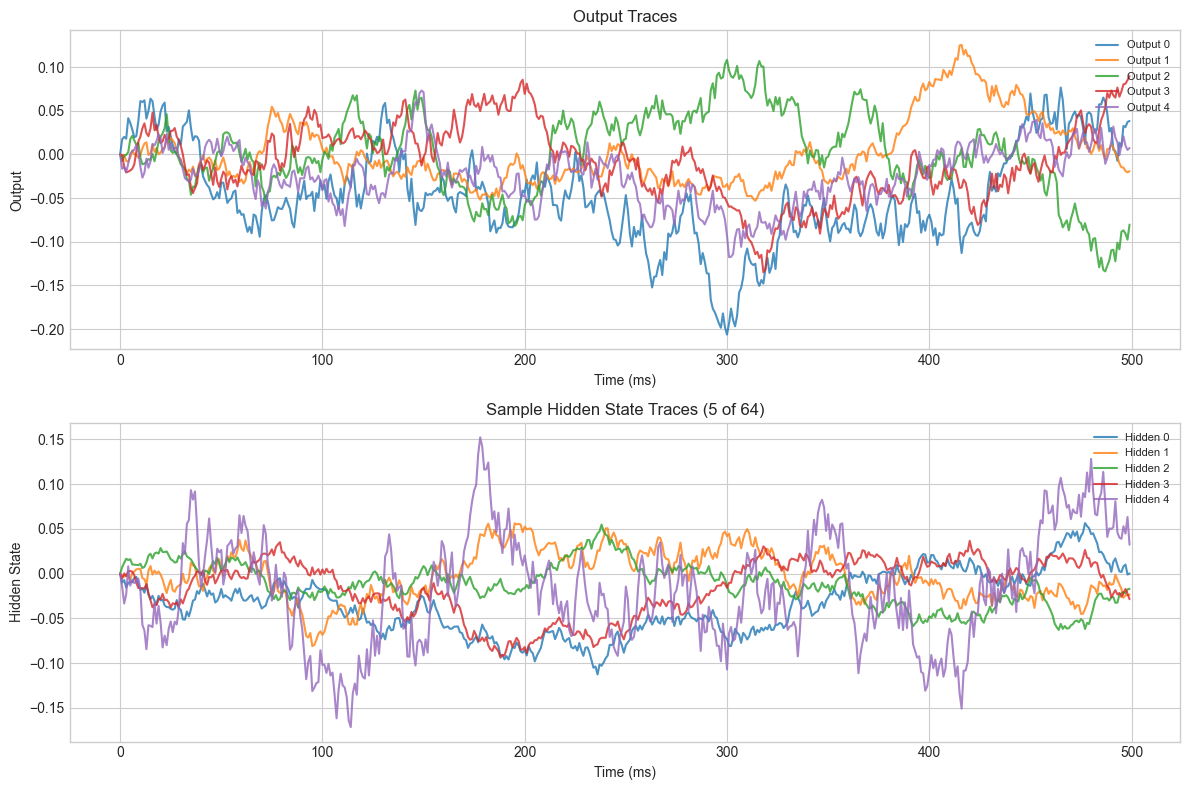

In [3]:
# Plot output traces
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

time = np.arange(n_steps) * dt_ms

# Plot outputs
ax = axes[0]
for i in range(n_outputs):
    ax.plot(time, outputs[:, i], label=f'Output {i}', alpha=0.8)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Output')
ax.set_title('Output Traces')
ax.legend(loc='upper right', fontsize=8)

# Plot a few hidden units
ax = axes[1]
n_plot = 5
for i in range(n_plot):
    ax.plot(time, states[:, i], label=f'Hidden {i}', alpha=0.8)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Hidden State')
ax.set_title(f'Sample Hidden State Traces ({n_plot} of {n_hidden})')
ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

## 2. Effect of Spectral Radius

The spectral radius controls the magnitude of recurrent weights. Higher values can lead to:
- Longer memory
- More oscillatory dynamics
- Potential instability if too high

In [4]:
# Sweep spectral radius values
spectral_radii = [0.3, 0.5, 0.7, 0.9, 1.1, 1.3]
n_systems = len(spectral_radii)

systems = []
for radius in spectral_radii:
    sys = ContinuousTimeRNN(
        n_hidden=n_hidden,
        n_inputs=n_inputs,
        n_outputs=n_outputs,
        spectral_radius=radius,
        sparsity=0.1,
        seed=42
    )
    systems.append(sys)

# Run same input through all systems
simulator = Simulator(systems[0], dt_ms=dt_ms)
all_outputs = simulator.run_with_multiple_systems(systems, inputs)

print(f"All outputs shape: {all_outputs.shape}")  # (n_systems, n_timesteps, n_outputs)

All outputs shape: (6, 500, 5)


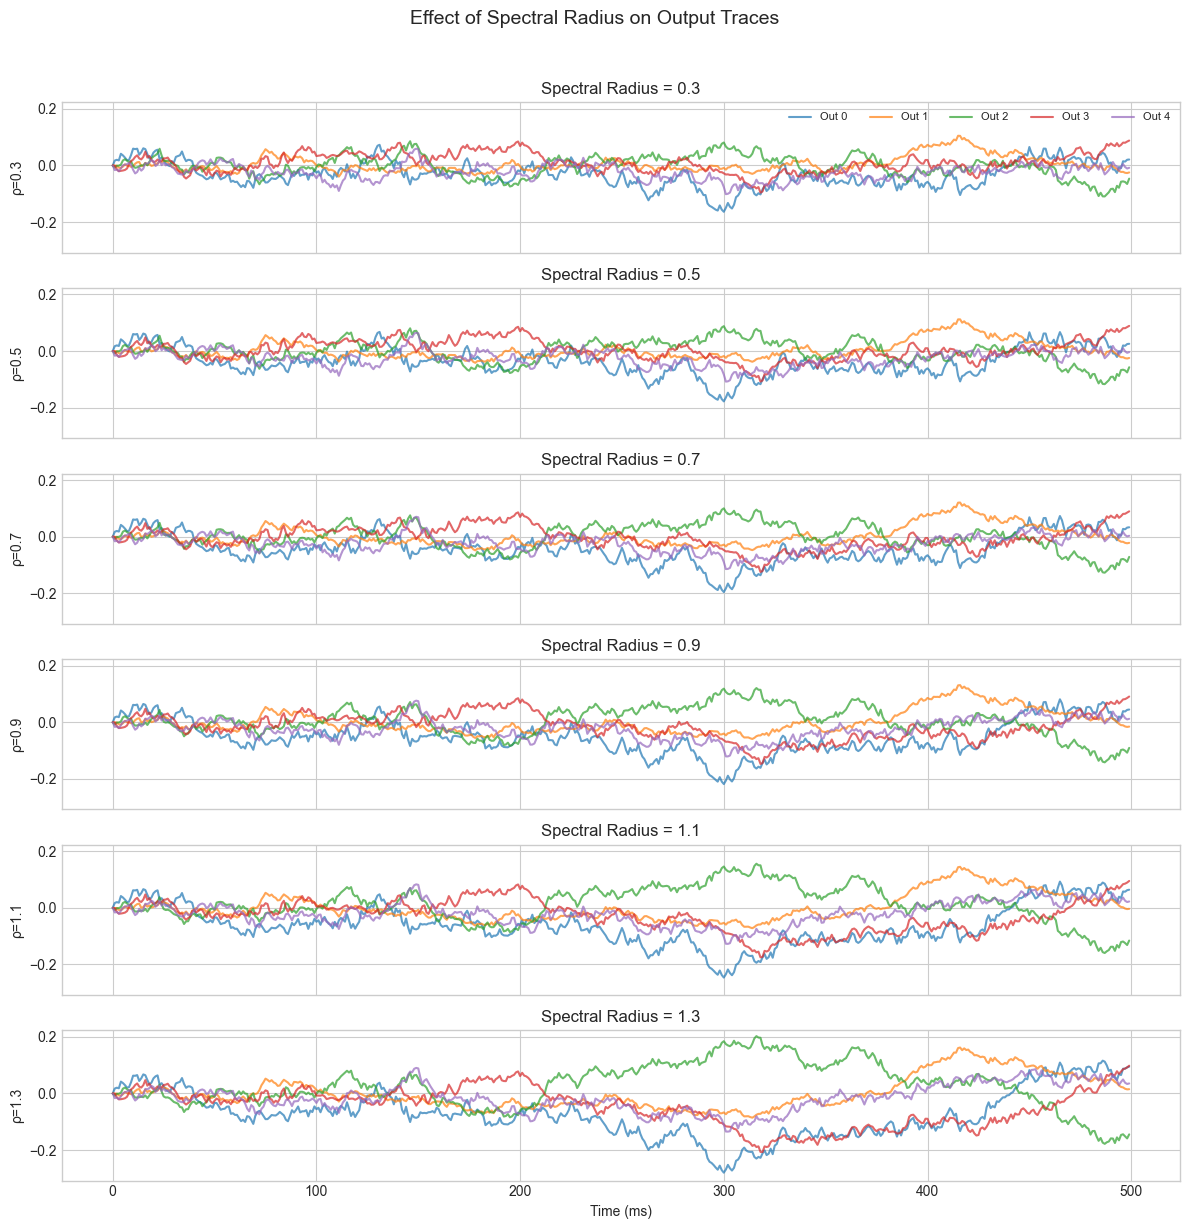

In [5]:
# Plot traces for different spectral radii
fig, axes = plt.subplots(n_systems, 1, figsize=(12, 2*n_systems), sharex=True)

for i, (ax, radius) in enumerate(zip(axes, spectral_radii)):
    for j in range(n_outputs):
        ax.plot(time, all_outputs[i, :, j], label=f'Out {j}', alpha=0.7)
    ax.set_ylabel(f'ρ={radius}')
    ax.set_title(f'Spectral Radius = {radius}')
    ax.set_ylim(all_outputs.min()*1.1, all_outputs.max()*1.1)

axes[-1].set_xlabel('Time (ms)')
axes[0].legend(loc='upper right', fontsize=8, ncol=n_outputs)
plt.suptitle('Effect of Spectral Radius on Output Traces', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

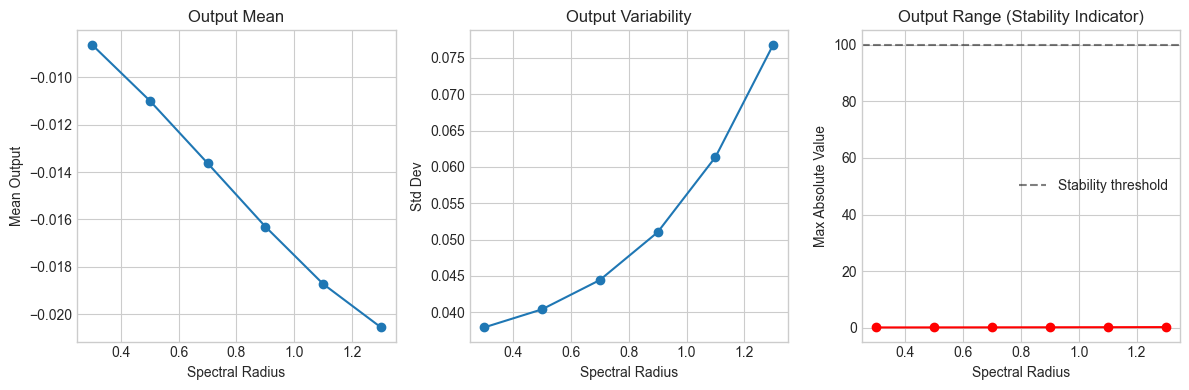

Spectral radii tested: [0.3, 0.5, 0.7, 0.9, 1.1, 1.3]
Output std by radius: {0.3: '0.04', 0.5: '0.04', 0.7: '0.04', 0.9: '0.05', 1.1: '0.06', 1.3: '0.08'}


In [6]:
# Compute and plot trace statistics
means = []
stds = []
max_vals = []

for i in range(n_systems):
    means.append(np.mean(all_outputs[i]))
    stds.append(np.std(all_outputs[i]))
    max_vals.append(np.max(np.abs(all_outputs[i])))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].plot(spectral_radii, means, 'o-')
axes[0].set_xlabel('Spectral Radius')
axes[0].set_ylabel('Mean Output')
axes[0].set_title('Output Mean')

axes[1].plot(spectral_radii, stds, 'o-')
axes[1].set_xlabel('Spectral Radius')
axes[1].set_ylabel('Std Dev')
axes[1].set_title('Output Variability')

axes[2].plot(spectral_radii, max_vals, 'o-', color='red')
axes[2].set_xlabel('Spectral Radius')
axes[2].set_ylabel('Max Absolute Value')
axes[2].set_title('Output Range (Stability Indicator)')
axes[2].axhline(y=100, color='k', linestyle='--', alpha=0.5, label='Stability threshold')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Spectral radii tested: {spectral_radii}")
print(f"Output std by radius: {dict(zip(spectral_radii, [f'{s:.2f}' for s in stds]))}")

## 3. Effect of Sparsity

Sparsity controls the fraction of non-zero recurrent connections. Higher sparsity means fewer connections.

In [7]:
# Sweep sparsity values
sparsity_values = [0.05, 0.1, 0.2, 0.4, 0.6, 0.8]
n_sparsity = len(sparsity_values)

sparse_systems = []
for sp in sparsity_values:
    sys = ContinuousTimeRNN(
        n_hidden=n_hidden,
        n_inputs=n_inputs,
        n_outputs=n_outputs,
        spectral_radius=0.8,
        sparsity=sp,
        seed=42
    )
    sparse_systems.append(sys)

# Run same input through all systems
simulator = Simulator(sparse_systems[0], dt_ms=dt_ms)
sparse_outputs = simulator.run_with_multiple_systems(sparse_systems, inputs)

print(f"Outputs shape: {sparse_outputs.shape}")

Outputs shape: (6, 500, 5)


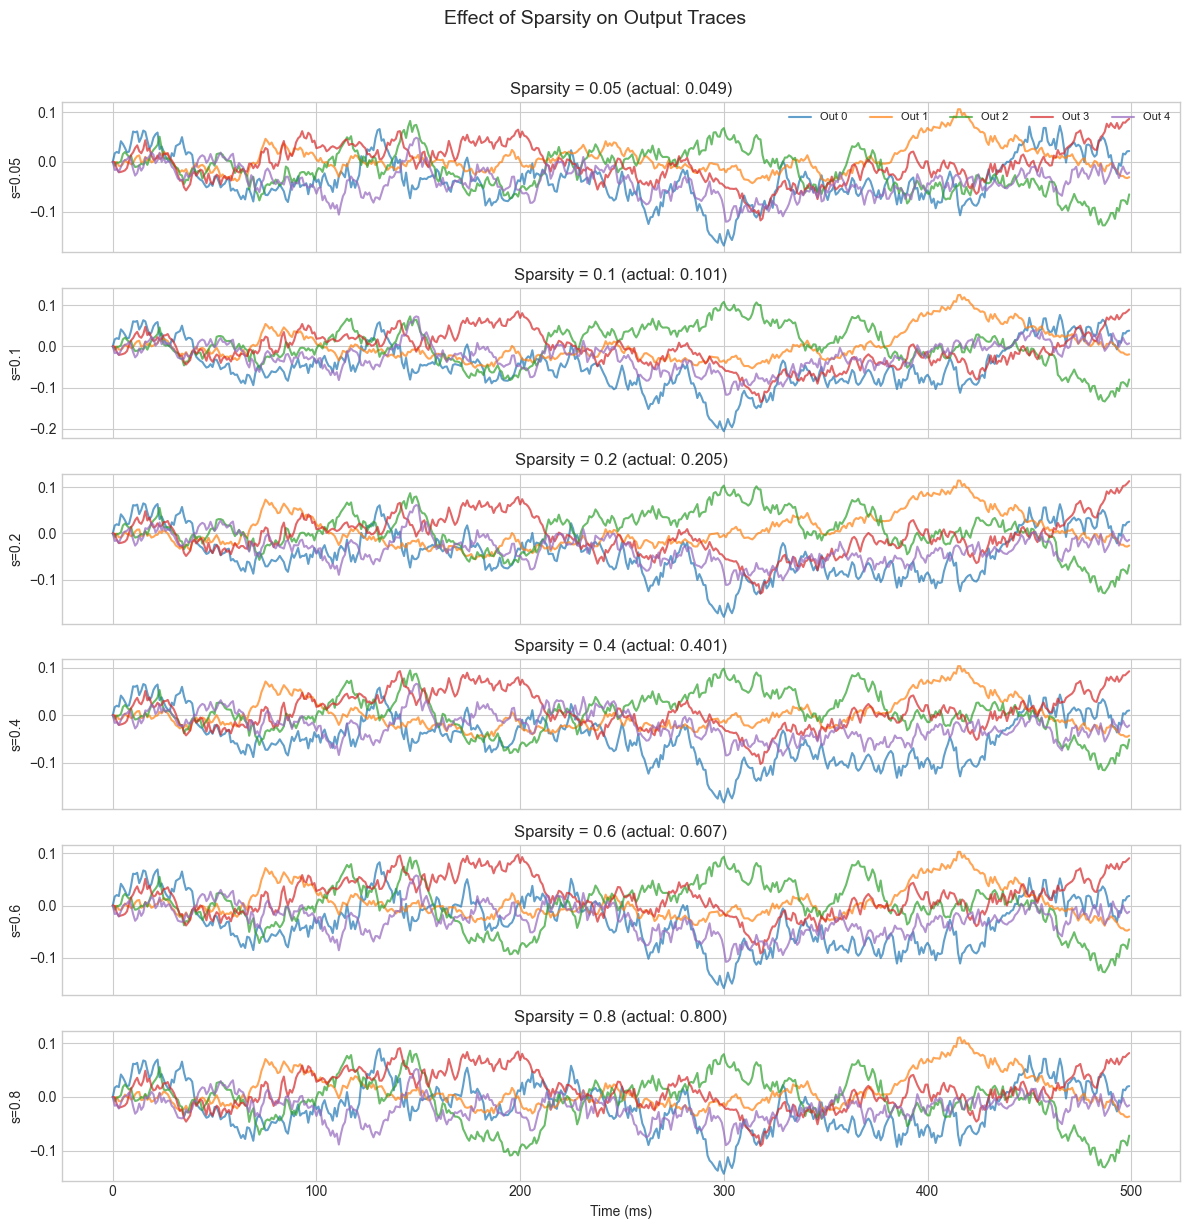

In [8]:
# Plot traces for different sparsity values
fig, axes = plt.subplots(n_sparsity, 1, figsize=(12, 2*n_sparsity), sharex=True)

for i, (ax, sp) in enumerate(zip(axes, sparsity_values)):
    for j in range(n_outputs):
        ax.plot(time, sparse_outputs[i, :, j], label=f'Out {j}', alpha=0.7)
    # Count actual non-zero weights
    nonzero = np.count_nonzero(sparse_systems[i].W_h)
    total = sparse_systems[i].W_h.size
    actual_sparsity = nonzero / total
    ax.set_ylabel(f's={sp}')
    ax.set_title(f'Sparsity = {sp} (actual: {actual_sparsity:.3f})')

axes[-1].set_xlabel('Time (ms)')
axes[0].legend(loc='upper right', fontsize=8, ncol=n_outputs)
plt.suptitle('Effect of Sparsity on Output Traces', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

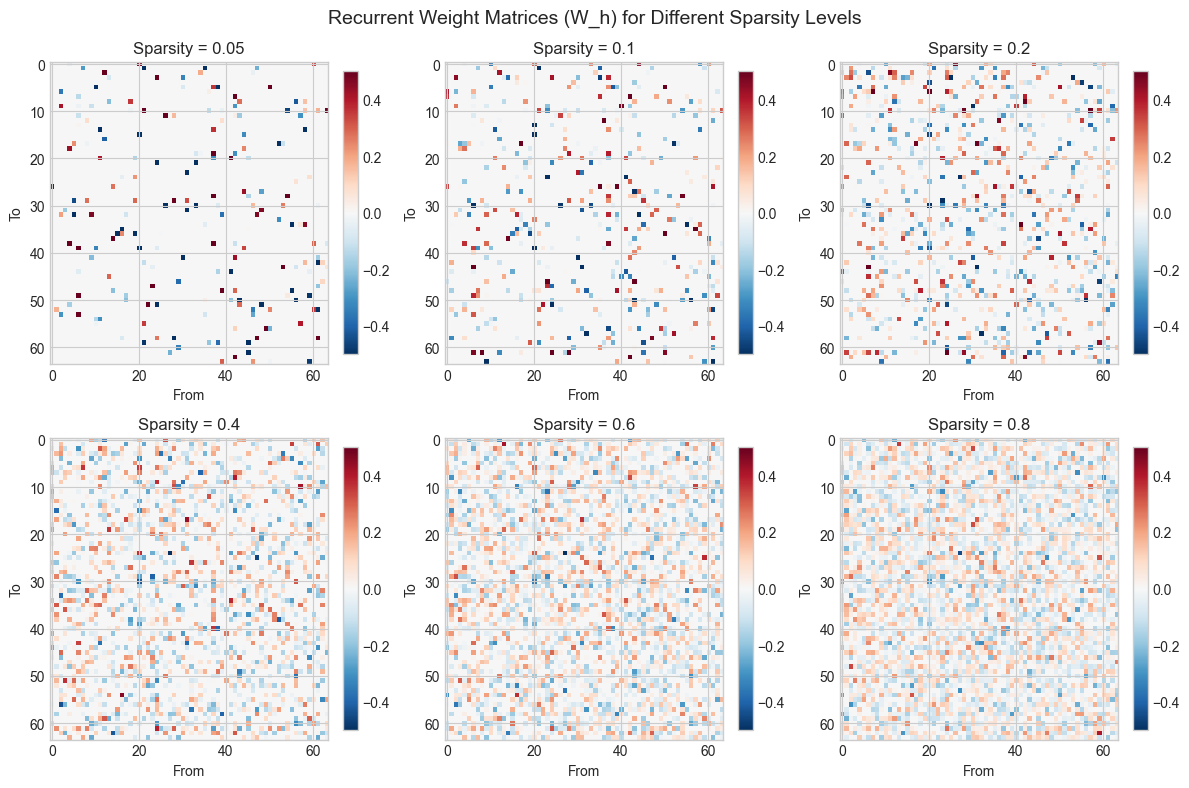

In [9]:
# Compare connectivity patterns
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, (ax, sp) in enumerate(zip(axes, sparsity_values)):
    im = ax.imshow(sparse_systems[i].W_h, cmap='RdBu_r', aspect='auto',
                   vmin=-0.5, vmax=0.5)
    ax.set_title(f'Sparsity = {sp}')
    ax.set_xlabel('From')
    ax.set_ylabel('To')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle('Recurrent Weight Matrices (W_h) for Different Sparsity Levels', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Effect of Timescale (tau)

Tau controls the speed of hidden state dynamics:
- Small tau (~10ms): Fast dynamics, rapid response
- Large tau (~100ms): Slow dynamics, longer memory
- Can be uniform or heterogeneous across units

In [10]:
# Test different tau configurations
tau_configs = [
    ('Fast (tau=10)', 10.0),
    ('Medium (tau=50)', 50.0),
    ('Slow (tau=100)', 100.0),
    ('Heterogeneous', np.linspace(10, 100, n_hidden)),
]

tau_systems = []
tau_labels = []
for label, tau in tau_configs:
    sys = ContinuousTimeRNN(
        n_hidden=n_hidden,
        n_inputs=n_inputs,
        n_outputs=n_outputs,
        tau=tau,
        spectral_radius=0.8,
        sparsity=0.1,
        seed=42
    )
    tau_systems.append(sys)
    tau_labels.append(label)

# Run simulation
simulator = Simulator(tau_systems[0], dt_ms=dt_ms)
tau_outputs = simulator.run_with_multiple_systems(tau_systems, inputs)

print(f"Outputs shape: {tau_outputs.shape}")

Outputs shape: (4, 500, 5)


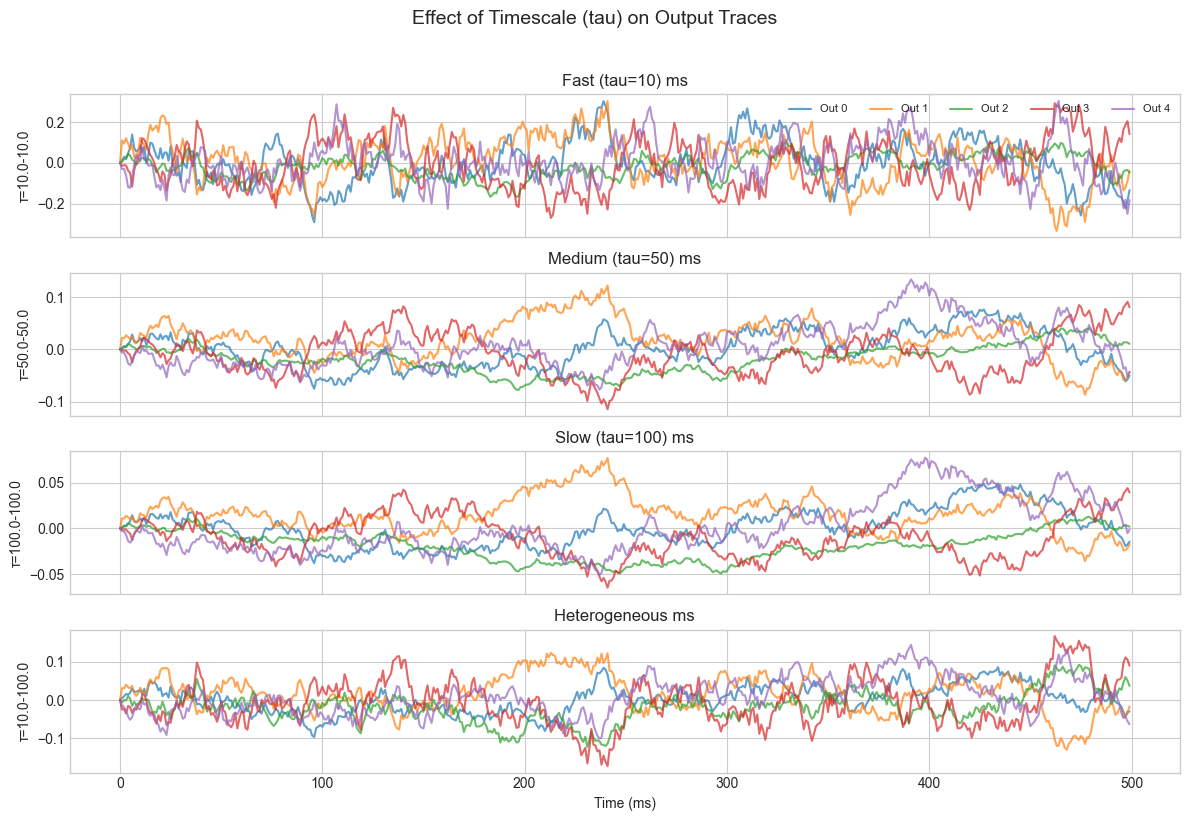

In [11]:
# Plot tau comparison
fig, axes = plt.subplots(len(tau_configs), 1, figsize=(12, 2*len(tau_configs)), sharex=True)

for i, (ax, label) in enumerate(zip(axes, tau_labels)):
    for j in range(n_outputs):
        ax.plot(time, tau_outputs[i, :, j], label=f'Out {j}', alpha=0.7)
    tau_info = tau_systems[i].tau
    if np.isscalar(tau_info) or tau_info.size == 1:
        tau_str = f'{float(tau_info):.1f}'
    else:
        tau_str = f'{tau_info.min():.1f}-{tau_info.max():.1f}'
    ax.set_ylabel(f'τ={tau_str}')
    ax.set_title(f'{label} ms')

axes[-1].set_xlabel('Time (ms)')
axes[0].legend(loc='upper right', fontsize=8, ncol=n_outputs)
plt.suptitle('Effect of Timescale (tau) on Output Traces', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

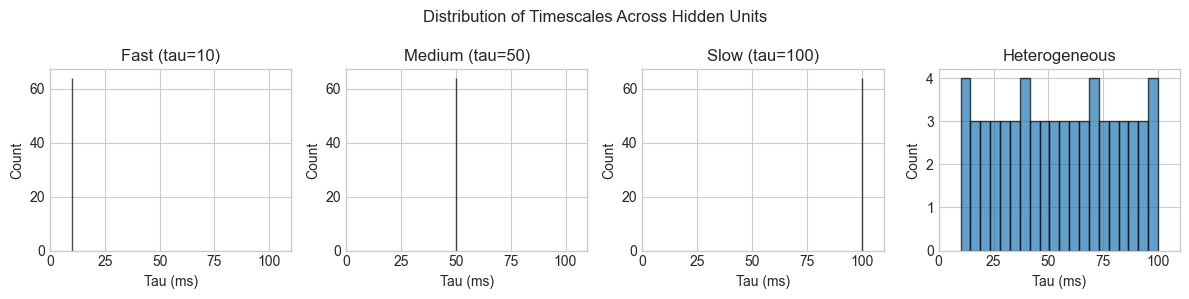

In [12]:
# Plot tau distributions for each system
fig, axes = plt.subplots(1, len(tau_configs), figsize=(12, 3))

for i, (ax, label) in enumerate(zip(axes, tau_labels)):
    tau_vals = tau_systems[i].tau
    if np.isscalar(tau_vals) or tau_vals.size == 1:
        tau_vals = np.full(n_hidden, float(tau_vals))
    ax.hist(tau_vals, bins=20, edgecolor='black', alpha=0.7)
    ax.set_xlabel('Tau (ms)')
    ax.set_ylabel('Count')
    ax.set_title(label)
    ax.set_xlim(0, 110)

plt.suptitle('Distribution of Timescales Across Hidden Units', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Hidden State Dynamics

Visualize how hidden states evolve over time for different parameter settings.

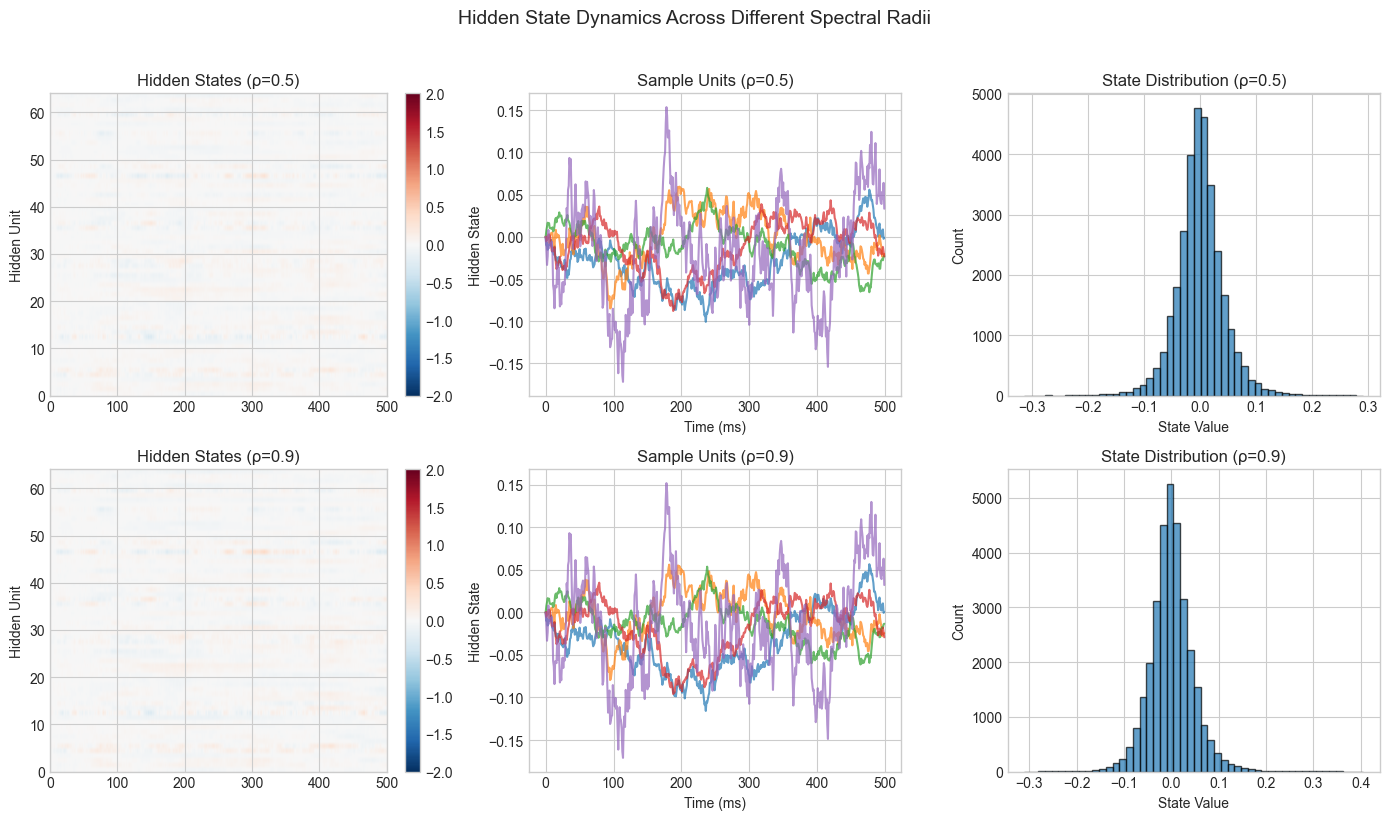

In [13]:
# Compare hidden state dynamics for different spectral radii
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for idx, (radius, ax_row) in enumerate(zip([0.5, 0.9, 1.2], [axes[0], axes[1]])):
    # Create system
    sys = ContinuousTimeRNN(
        n_hidden=n_hidden,
        n_inputs=n_inputs,
        n_outputs=n_outputs,
        spectral_radius=radius,
        sparsity=0.1,
        seed=42
    )
    
    # Run and record states
    sim = Simulator(sys, dt_ms=dt_ms)
    out, states = sim.run(inputs, record_states=True)
    
    # Plot hidden state heatmap
    ax = ax_row[0]
    im = ax.imshow(states.T, aspect='auto', cmap='RdBu_r',
                   extent=[0, duration_ms, 0, n_hidden],
                   vmin=-2, vmax=2)
    ax.set_ylabel('Hidden Unit')
    ax.set_title(f'Hidden States (ρ={radius})')
    plt.colorbar(im, ax=ax, fraction=0.046)
    
    # Plot sample traces
    ax = ax_row[1]
    for i in range(5):
        ax.plot(time, states[:, i], alpha=0.7)
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Hidden State')
    ax.set_title(f'Sample Units (ρ={radius})')
    
    # Plot state distribution
    ax = ax_row[2]
    ax.hist(states.flatten(), bins=50, edgecolor='black', alpha=0.7)
    ax.set_xlabel('State Value')
    ax.set_ylabel('Count')
    ax.set_title(f'State Distribution (ρ={radius})')

plt.suptitle('Hidden State Dynamics Across Different Spectral Radii', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Interactive Parameter Exploration

Generate multiple random systems with the same parameters to see sample variability.

In [14]:
# Generate multiple systems with same parameters but different random seeds
n_samples = 5
base_params = {
    'n_hidden': n_hidden,
    'n_inputs': n_inputs,
    'n_outputs': n_outputs,
    'spectral_radius': 0.8,
    'sparsity': 0.1
}

sample_systems = []
for i in range(n_samples):
    sys = ContinuousTimeRNN(seed=i, **base_params)
    sample_systems.append(sys)

# Run all systems
simulator = Simulator(sample_systems[0], dt_ms=dt_ms)
sample_outputs = simulator.run_with_multiple_systems(sample_systems, inputs)

print(f"Sample outputs shape: {sample_outputs.shape}")

Sample outputs shape: (5, 500, 5)


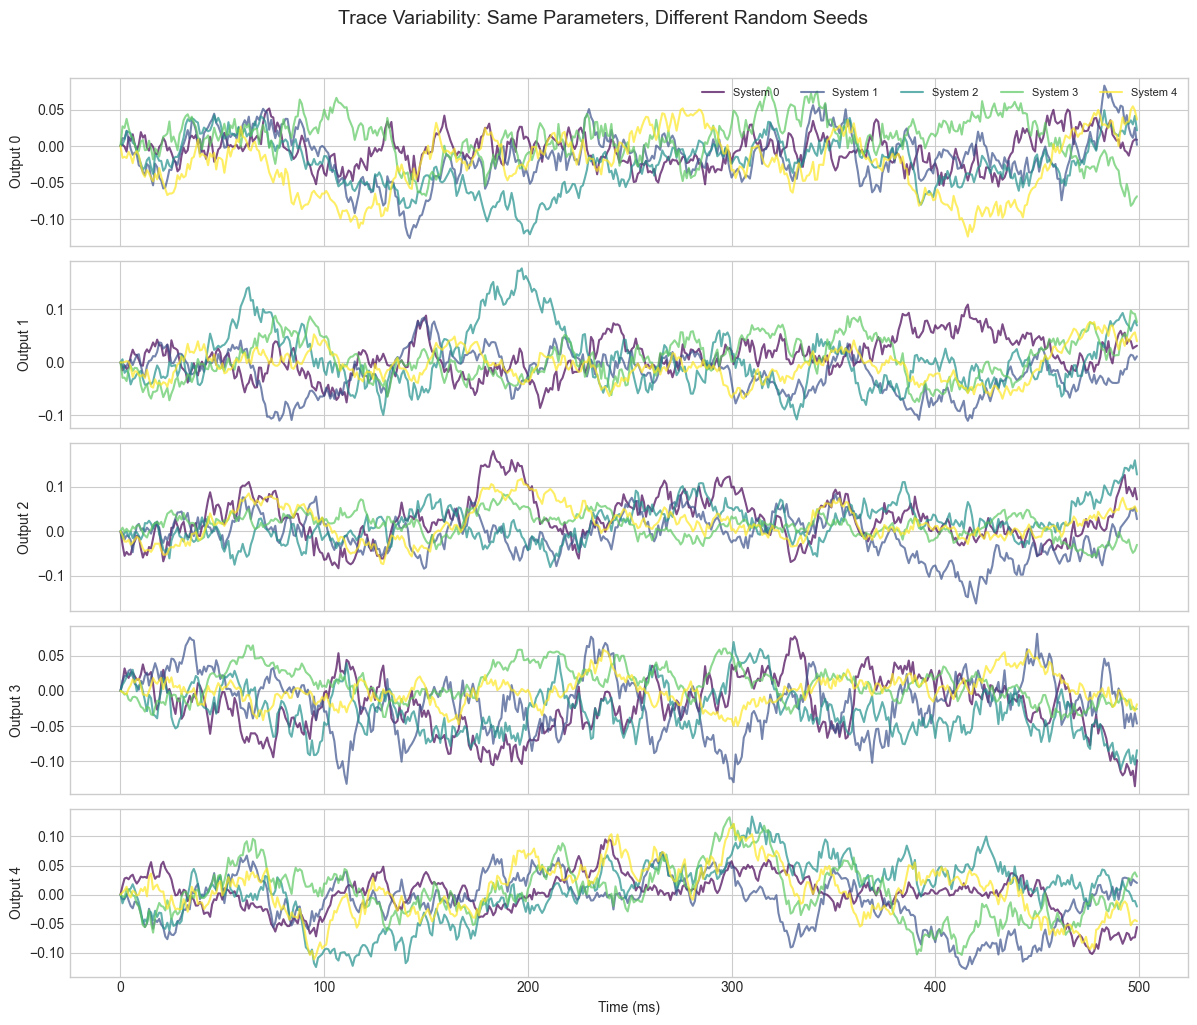

In [15]:
# Plot sample variability
fig, axes = plt.subplots(n_outputs, 1, figsize=(12, 2*n_outputs), sharex=True)

if n_outputs == 1:
    axes = [axes]

colors = plt.cm.viridis(np.linspace(0, 1, n_samples))

for out_idx, ax in enumerate(axes):
    for sample_idx in range(n_samples):
        ax.plot(time, sample_outputs[sample_idx, :, out_idx],
                color=colors[sample_idx], alpha=0.7,
                label=f'System {sample_idx}')
    ax.set_ylabel(f'Output {out_idx}')
    if out_idx == 0:
        ax.legend(loc='upper right', fontsize=8, ncol=n_samples)

axes[-1].set_xlabel('Time (ms)')
plt.suptitle('Trace Variability: Same Parameters, Different Random Seeds', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

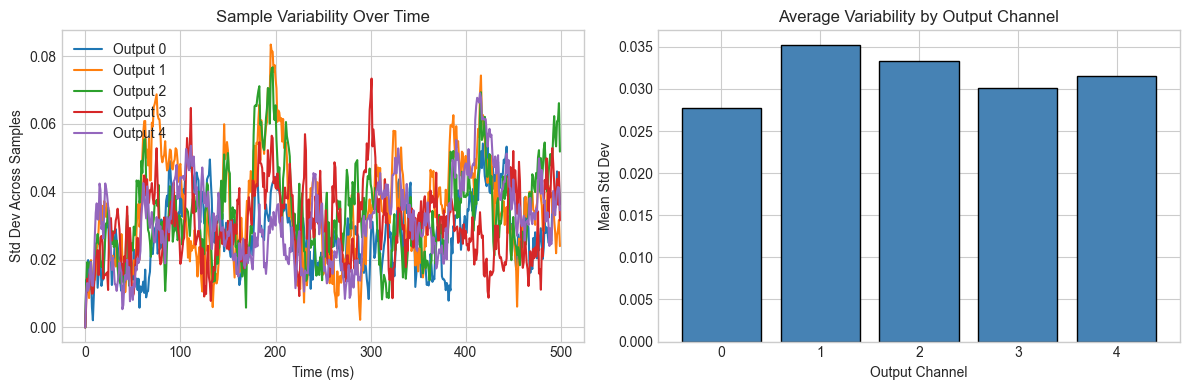

Mean variability by output: {0: '0.028', 1: '0.035', 2: '0.033', 3: '0.030', 4: '0.032'}


In [16]:
# Compute variability statistics
# For each output, compute std across samples at each timepoint
output_variability = np.std(sample_outputs, axis=0)  # (n_timesteps, n_outputs)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot variability over time
ax = axes[0]
for i in range(n_outputs):
    ax.plot(time, output_variability[:, i], label=f'Output {i}')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Std Dev Across Samples')
ax.set_title('Sample Variability Over Time')
ax.legend()

# Plot mean variability per output
ax = axes[1]
mean_var = np.mean(output_variability, axis=0)
ax.bar(range(n_outputs), mean_var, color='steelblue', edgecolor='black')
ax.set_xlabel('Output Channel')
ax.set_ylabel('Mean Std Dev')
ax.set_title('Average Variability by Output Channel')
ax.set_xticks(range(n_outputs))

plt.tight_layout()
plt.show()

print(f"Mean variability by output: {dict(zip(range(n_outputs), [f'{v:.3f}' for v in mean_var]))}")

## 7. Summary: Parameter Effects

Quick comparison of all parameter sweeps.

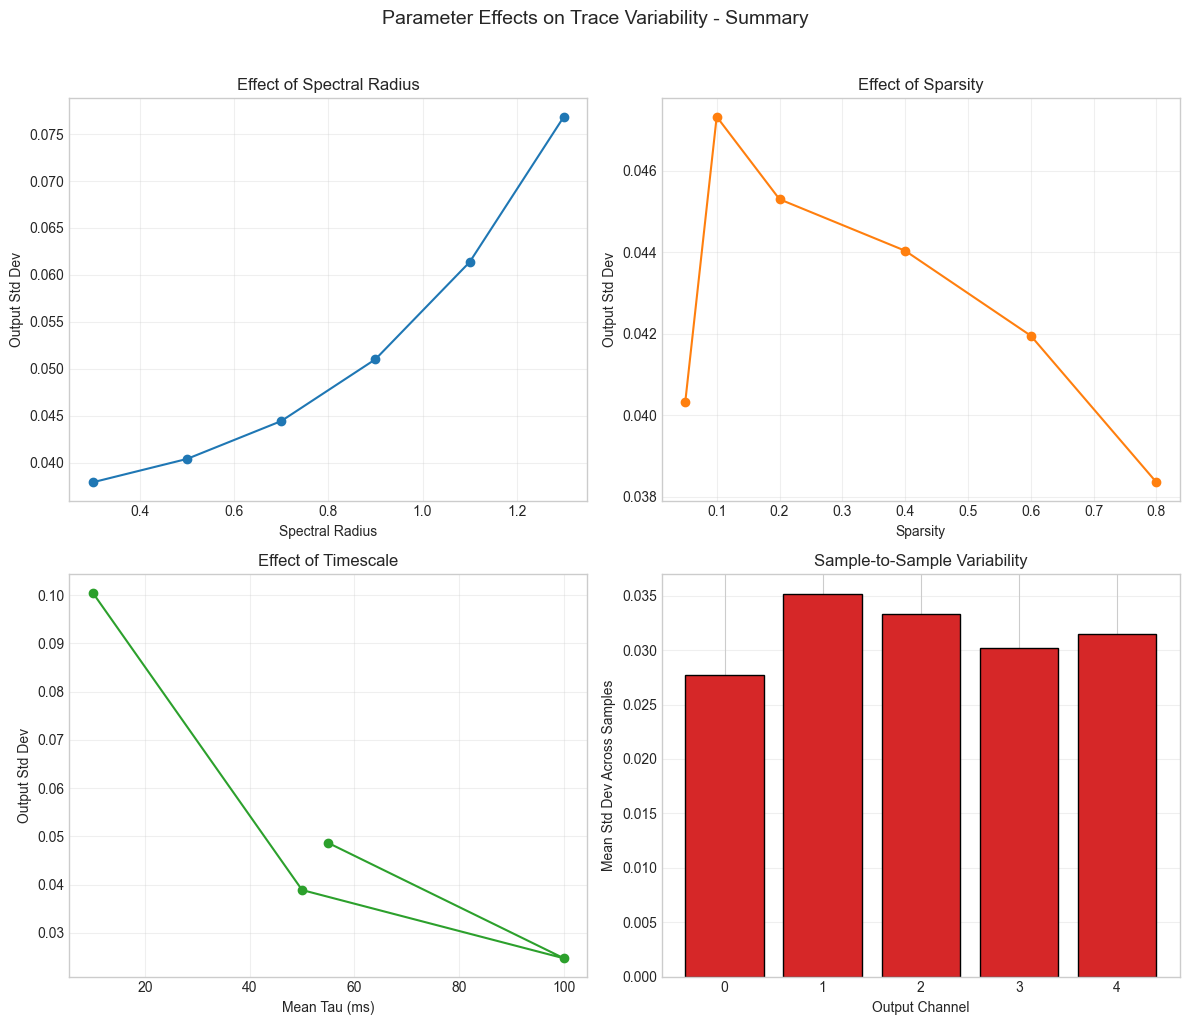

In [17]:
# Summary figure comparing all parameter effects
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Spectral radius effect
ax = axes[0, 0]
radii_std = [np.std(all_outputs[i]) for i in range(n_systems)]
ax.plot(spectral_radii, radii_std, 'o-', color='C0')
ax.set_xlabel('Spectral Radius')
ax.set_ylabel('Output Std Dev')
ax.set_title('Effect of Spectral Radius')
ax.grid(True, alpha=0.3)

# Sparsity effect
ax = axes[0, 1]
sparsity_std = [np.std(sparse_outputs[i]) for i in range(n_sparsity)]
ax.plot(sparsity_values, sparsity_std, 'o-', color='C1')
ax.set_xlabel('Sparsity')
ax.set_ylabel('Output Std Dev')
ax.set_title('Effect of Sparsity')
ax.grid(True, alpha=0.3)

# Tau effect
ax = axes[1, 0]
tau_means = []
for i in range(len(tau_configs)):
    tau_val = tau_systems[i].tau
    if not (np.isscalar(tau_val) or tau_val.size == 1):
        tau_val = np.mean(tau_val)
    tau_means.append(float(tau_val))
tau_std = [np.std(tau_outputs[i]) for i in range(len(tau_configs))]
ax.plot(tau_means, tau_std, 'o-', color='C2')
ax.set_xlabel('Mean Tau (ms)')
ax.set_ylabel('Output Std Dev')
ax.set_title('Effect of Timescale')
ax.grid(True, alpha=0.3)

# Sample variability
ax = axes[1, 1]
ax.bar(range(n_outputs), mean_var, color='C3', edgecolor='black')
ax.set_xlabel('Output Channel')
ax.set_ylabel('Mean Std Dev Across Samples')
ax.set_title('Sample-to-Sample Variability')
ax.set_xticks(range(n_outputs))
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Parameter Effects on Trace Variability - Summary', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Key Takeaways

1. **Spectral Radius (ρ)**: Higher values increase output variability and can lead to instability when ρ > 1.

2. **Sparsity**: Lower sparsity (denser connections) tends to increase variability. Very high sparsity can reduce system expressiveness.

3. **Timescale (τ)**: Slower dynamics (larger τ) create smoother traces with less high-frequency content.

4. **Sample Variability**: Even with identical parameters, different random seeds produce noticeably different traces due to random weight initialization.

These parameters can be tuned to achieve desired dynamical regimes for specific tasks.